### 2.1.4 高斯过程建模

高斯过程（GP）可为上一节介绍的克里金插值方法提供贝叶斯层面的解释。柯林等人于 1991 年将高斯过程引入计算机实验领域，而在此之前该方法已应用于其他场景（瓦巴，1978；奥哈根，1978）。拉斯穆森与威廉姆斯在 2006 年出版的著作推动了高斯过程在机器学习领域的应用发展。桑特纳等人（2018）与格拉马西（2020）各自所著书籍中，详细阐述了高斯过程在计算机实验中的运用。

> **定义 2.3** 若对于任意选取的 $\boldsymbol{x}_1,\dots,\boldsymbol{x}_n$ 以及任意整数 $n \ge 1$，向量 $\boldsymbol{Y} = (Y(\boldsymbol{x}_1),\dots,Y(\boldsymbol{x}_n))'$ 服从多元正态分布，则称随机函数 $Y(\boldsymbol{x})$ 为高斯过程。

回顾可知，n 维多元正态分布由均值 $\boldsymbol{\mu} \in \mathbb{R}^n$ 与协方差矩阵 $\boldsymbol{\Sigma} \in \mathbb{R}^{n\times n}$ 唯一确定。因此若 $\boldsymbol{y} \sim \mathcal{N}_n(\boldsymbol{\boldsymbol{\mu}}, \boldsymbol{\Sigma})$，其概率密度表达式为：

$$
f(\boldsymbol{y}) = \frac{1}{(2\pi)^{n/2}|\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2}(\boldsymbol{y}-\boldsymbol{\boldsymbol{\mu}})' \boldsymbol{\Sigma}^{-1}(\boldsymbol{y}-\boldsymbol{\boldsymbol{\mu}}) \right]
$$

高斯过程（GP）可看作多元正态分布在连续维度上的拓展形式，它由均值函数 $\mu(\boldsymbol{x})$ 以及协方差函数（也称核函数）$K(\boldsymbol{x},\cdot)$ 共同定义，其中 $\mu(\boldsymbol{x}) = E\{Y(\boldsymbol{x})\}$，$K(\boldsymbol{x},\boldsymbol{u}) = cov\{Y(\boldsymbol{x}),Y(\boldsymbol{u})\}$。

我们希望基于数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$ 估算真实的输入输出关系 $y = h(\boldsymbol{x})$。采用贝叶斯方法时，先为函数 $h(\boldsymbol{x})$ 设定先验分布，再结合观测数据求解 $h(\boldsymbol{x})$ 的后验分布。相较于观测数据前对函数 $h(\boldsymbol{x})$ 的先验认知，后验分布能够帮助我们更精准地掌握该函数的特性。本文将高斯过程（GP）作为 $h(\boldsymbol{x})$ 的先验分布，即：

$$
h(\boldsymbol{x}) \sim GP(\mu(\boldsymbol{x}), K(\boldsymbol{x}, \cdot))
\tag{2.17}
$$

本书后续大部分推导过程中，均假定均值函数 $\mu(\boldsymbol{x}) = \mu$（常数），协方差核函数 $K(\boldsymbol{x}, \boldsymbol{u}) = \tau^2 R(\boldsymbol{x}-\boldsymbol{u})$，其中 $\tau^2$ 代表方差，$R(\cdot)$ 为相关函数。取一维输入变量、相关函数 $R(\boldsymbol{x})=e^{-\boldsymbol{x}^2/\theta^2}$、参数 $\theta=0.08$ 时，几组高斯过程的采样实现结果如图 2.5 左图所示。假设我们对该函数进行采样观测，得到的数据以蓝色圆点绘制于同一张图的中间子图。我们的目标是结合观测数据，求解该函数的后验分布。

> **图 2.5** 左侧为先验高斯过程生成的五组实现样本，中间为叠加在先验之上的数据，右侧为后验高斯过程生成的五组实现样本。

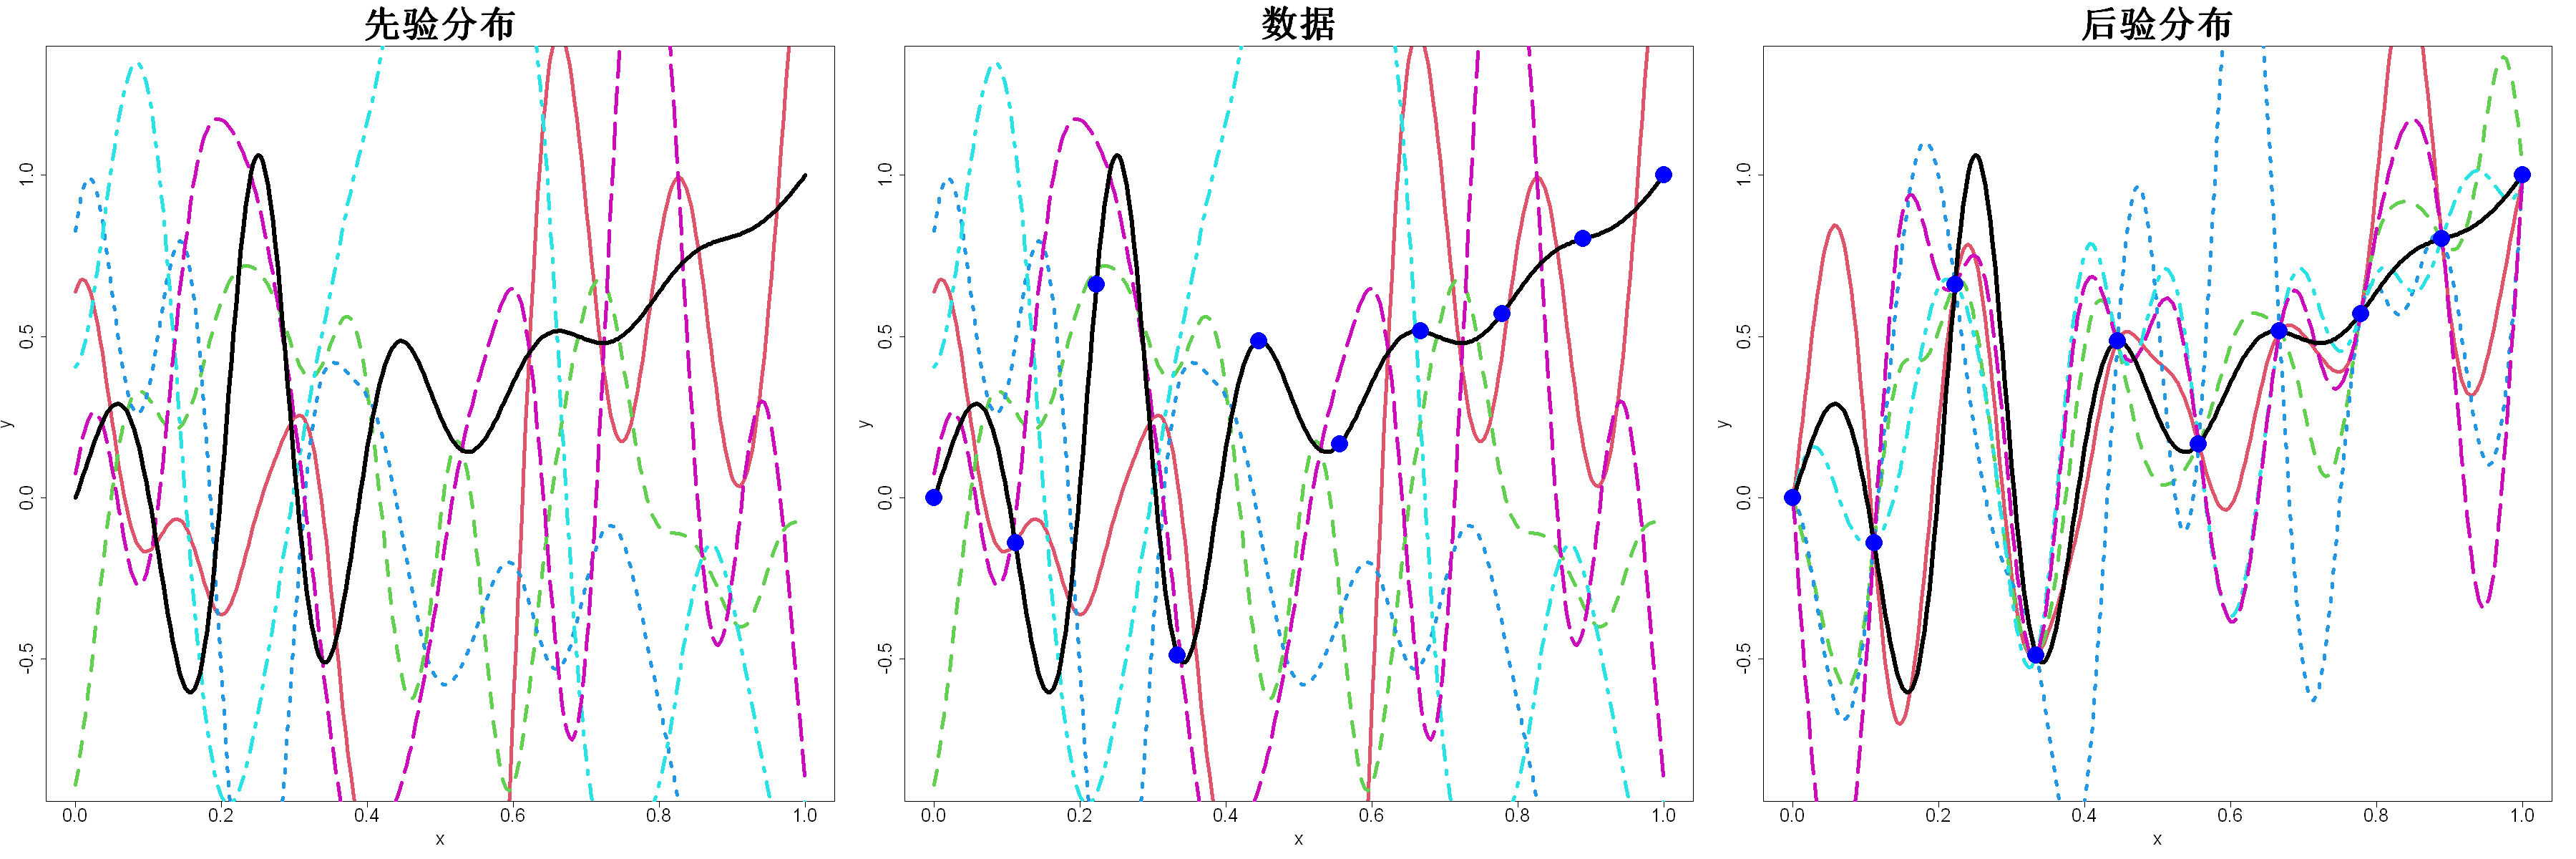

In [6]:
options(repr.plot.width=30,repr.plot.height=10)
library(DiceKriging)
library(MASS)
par(mfrow=c(1,3))

f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
N=301
test=matrix(seq(0,1,length=301),ncol=1,dimnames=list(NULL,"x"))
true=f(test[,1])
n=10
D=matrix(((1:n)-1)/(n-1),ncol=1,dimnames=list(NULL,"x"))
y=f(D[,1])

theta=.08
km.model=km(~1,design=as.matrix(D),response=y,covtype="gauss",coef.cov=theta,coef.var=1,penalty=FALSE,control=list(trace=FALSE))
pred.obj=predict(km.model,as.matrix(test),type="SK")
mu_hat=km.model@trend.coef
tau2_hat=km.model@covariance@sd2
pred=pred.obj$mean

x_test=as.numeric(test[,1])
x_D=as.numeric(D[,1])
S0=exp(-(outer(x_test,x_test,"-")/theta)^2)
R_pred=exp(-(outer(x_test,x_D,"-")/theta)^2)
R_inv=solve(exp(-(outer(x_D,x_D,"-")/theta)^2))

set.seed(1)
u=mvrnorm(n=5,mu=rep(0,N),Sigma=tau2_hat*S0)
matplot(test,t(u),type="l",xlab="x",ylab="y",col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),main="先验分布",cex.main=4,cex.axis=2,cex.lab=2)
lines(test,true,type="l",lwd=5)
matplot(test,t(u),type="l",xlab="x",ylab="y",col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),main="数据",cex.main=4,cex.axis=2,cex.lab=2)
lines(test,true,type="l",lwd=5)
points(cbind(D,y),pch=16,cex=4,col="blue")

S=tau2_hat*(S0-R_pred%*%R_inv%*%t(R_pred))
u=mvrnorm(n=5,mu=pred,Sigma=S)
matplot(test,t(u),type="l",xlab="x",ylab="y",col=2:6,lwd=4,ylim=c(min(true)-.25,max(true)+.25),main="后验分布",cex.main=4,cex.axis=2,cex.lab=2)
lines(test,true,type="l",lwd=5)
points(cbind(D,y),pch=16,cex=4,col="blue")
par(mfrow=c(1,1))

概率论中的下述结论有助于推导后验分布。

> **引理 2.2** 设 $\boldsymbol{y} = (\boldsymbol{y}_1', \boldsymbol{y}_2')'$，其中 $\boldsymbol{y}_1 \in \mathbb{R}^{n_1}$，$\boldsymbol{y}_2 \in \mathbb{R}^{n_2}$。若
> $$\begin{bmatrix}\boldsymbol{y}_{1}\\\boldsymbol{y}_{2}\end{bmatrix}\sim\mathcal{N}\left(\begin{bmatrix}\boldsymbol{\mu}_{1}\\\boldsymbol{\mu}_{2}\end{bmatrix},\begin{bmatrix}\boldsymbol{\Sigma}_{11}&\boldsymbol{\Sigma}_{12}\\\boldsymbol{\Sigma}_{21}&\boldsymbol{\Sigma}_{22}\end{bmatrix}\right)$$
> 则
> $$\boldsymbol{y}_{1}|\boldsymbol{y}_{2}\sim\mathcal{N}_{n_{1}}(\boldsymbol{\mu}_{1}+\boldsymbol{\Sigma}_{12}\boldsymbol{\Sigma}_{22}^{-1}(\boldsymbol{y}_{2}-\boldsymbol{\mu}_{2}),\boldsymbol{\Sigma}_{11}-\boldsymbol{\Sigma}_{12}\boldsymbol{\Sigma}_{22}^{-1}\boldsymbol{\Sigma}_{21})$$

暂且假定模型参数 $\mu$、$\tau^2$ 以及相关函数中的参数 $\boldsymbol{\theta}$ 均为已知。对于给定的 $\boldsymbol{x}$，式 (2.17) 可得

$$
\begin{bmatrix}
h(\boldsymbol{x})\\\boldsymbol{y}
\end{bmatrix}
\sim N_{1+n}
\left(
\begin{bmatrix}\mu\\\mu\boldsymbol{1}\end{bmatrix},
\begin{bmatrix}
\tau^2 & \tau^2\boldsymbol{r}(\boldsymbol{x})^\prime \\
\tau^2\boldsymbol{r}(\boldsymbol{x}) & \tau^2\boldsymbol{R}
\end{bmatrix}
\right)
$$

其中 $\boldsymbol{r}(\boldsymbol{x})=\{R(\boldsymbol{x}-\boldsymbol{x}_i)\}_{i=1}^n$，$\boldsymbol{R}=\{R(\boldsymbol{x}_i-\boldsymbol{x}_j)\}_{i,j=1}^n$，定义同式 (2.13)。结合引理 2.2，可求得给定 $\boldsymbol{y}$ 时 $h(\boldsymbol{x})$ 的后验分布：

$$
h(\boldsymbol{x})|\boldsymbol{y} \sim N\left(\mu+\boldsymbol{r}(\boldsymbol{x})^\prime\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}),\;\tau^2\left\{1-\boldsymbol{r}(\boldsymbol{x})^\prime\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}\right) \tag{2.18}
$$

若需要 $h(\boldsymbol{x})$ 的点估计，可取后验均值 $\hat{y}(\boldsymbol{x}) = \mu+\boldsymbol{r}(\boldsymbol{x})^\prime\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})$，该表达式与式 (2.14) 中的克里金预测式形式一致，区别仅在于此处假定 $\mu$ 已知。预测方差 $s^2(\boldsymbol{x}) = \tau^2\left\{1-\boldsymbol{r}(\boldsymbol{x})^\prime\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}$ 可用于量化预测的不确定性，该方差与式 (2.16) 中普通克里金的均方误差 $MSE(\boldsymbol{x})$ 相比仅缺少最后一项。后文将会说明，式 (2.16) 多出的这一项，正是因 $\mu$ 未知所带来的额外预测不确定性。据此可以构造置信水平为 $1-\alpha$ 的可信区间：$\hat{y}(\boldsymbol{x}) \pm z_{1-\alpha/2}s(\boldsymbol{x})$，式中 $z_{1-\alpha/2}$ 为标准正态分布的上 $1-\alpha/2$ 分位数。

式 (2.18) 可给出给定某一特定 $\boldsymbol{x}$ 取值时 $h(\boldsymbol{x})$ 的后验分布。同理，我们能够求得一组 $\boldsymbol{x}$ 取值对应的 $h(\boldsymbol{x})$ 后验分布，由此可证明整个函数 $h(\boldsymbol{x})$ 的后验分布服从高斯过程（GP）：

$$
h(\boldsymbol{x})|\boldsymbol{y} \sim GP\left( \mu + \boldsymbol{r}(\boldsymbol{x})^\prime \boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}), \tau^2\left\{R(\boldsymbol{x}-\cdot)-\boldsymbol{r}(\boldsymbol{x})^\prime\boldsymbol{R}^{-1}\boldsymbol{r}(\cdot)\right\} \right)
\tag{2.19}
$$

图 2.5 右侧子图还绘制出了当参数 $\theta=0.08$ 时该高斯过程的若干采样实现。不难发现，所有采样曲线均穿过数据点，并且相较于先验分布，函数 $h(\boldsymbol{x})$ 整体的不确定性大幅降低。

若要使用高斯过程（GP）开展预测工作，必须预先设定（超）参数 $\mu$、$\tau^2$ 与 $\boldsymbol{\theta}$。贝叶斯建模框架为这类参数的估计提供了一套严谨可行的方法，经验贝叶斯方法便是其中一种简便方案。数据的边缘分布满足：

$$
\boldsymbol{y}|\mu,\tau^{2},\boldsymbol{\theta}\sim\mathcal{N}_{n}(\mu\boldsymbol{1},\tau^{2}\boldsymbol{R})
$$

据此可得参数的似然函数：

$$
L=\frac{1}{(2\pi\tau^{2})^{n/2}|\boldsymbol{R}|^{1/2}}\exp\left\{-\frac{1}{2\tau^{2}}(\boldsymbol{y}-\mu\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})\right\}
$$

对数似然表达式为：

$$
\log L = -\frac{n}{2}\log 2\pi -\frac{n}{2}\log\tau^2 -\frac{1}{2}\log|\boldsymbol{R}| -\frac{1}{2\tau^2}(\boldsymbol{y} -\mu\boldsymbol{1})' \boldsymbol{R}^{-1}(\boldsymbol{y} -\mu\boldsymbol{1})
$$

将对数似然关于 $\mu$、$\tau^2$ 最大化，求得估计量：

$$
\hat{\mu}=\frac{\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{y}}{\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}}\tag{2.20}
$$

$$
\hat{\tau}^2= \frac{1}{n}(\boldsymbol{y} -\hat{\mu}\boldsymbol{1})' \boldsymbol{R}^{-1}(\boldsymbol{y} -\hat{\mu}\boldsymbol{1}) \tag{2.21}
$$

对数似然函数关于相关参数 $\boldsymbol{\theta}$ 呈高度非线性，因此很难推导出 $\boldsymbol{\theta}$ 显式解析解。我们可将 $\mu$ 与 $\tau^2$ 代入对数似然式，构造 $\boldsymbol{\theta}$ 的剖面对数似然函数，并通过数值最大化该函数求解 $\boldsymbol{\theta}$ 的估计值。等价形式如下：

$$
\hat{\boldsymbol{\theta}}=\argmin_{\boldsymbol{\theta}}\left\{ n\log\hat{\tau}^2 + \log|\boldsymbol{R}| \right\}
\tag{2.22}
$$

经验贝叶斯的替代方法是分层贝叶斯，该方法可为所有超参数设置先验分布，并求解它们的后验分布。但完整贝叶斯推断的计算量很大，因为需要借助马尔可夫链蒙特卡罗（MCMC）算法才能得到参数 $\boldsymbol{\theta}$ 的后验分布。下文仅对均值 $\mu$ 设置先验分布，以此演示分层贝叶斯方法。如需完整论述，可参阅桑特纳等人（2018，第 4 章）的著作。

假设均值 $\mu$ 服从无信息先验分布：

$$
p(\mu) \propto 1
$$

于是可得：

$$
\begin{align*}
p(\mu|\boldsymbol{y})&\propto p(\boldsymbol{y}|\mu)p(\mu)\\
&\propto\exp\left\{-\frac{1}{2\tau^{2}}(\boldsymbol{y}-\mu\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})\right\}
\end{align*}
$$

方差分析（ANOVA）分解的下述推广形式，将有助于我们后续推导。

> **引理 2.3** 设 $\hat{\mu}=\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{y}/\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}$，则有
> $$(\boldsymbol{y}-\mu\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})=(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})+(\mu-\hat{\mu})^{2}\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}$$

引理 2.3 表明

$$
\begin{align*}
p(\mu|\boldsymbol{y})&\propto\exp\left\{-\frac{1}{2\tau^{2}}\left[(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})'\boldsymbol{R}^{-1}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})+(\mu-\hat{\mu})^{2}\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}\right]\right\}\\
&\propto\exp\left\{-\frac{1}{2\tau^{2}}(\mu-\hat{\mu})^{2}\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}\right\}
\end{align*}
$$

因此

$$
\mu|\boldsymbol{y}\sim\mathcal{N}\left(\hat{\mu},\frac{\tau^{2}}{\boldsymbol{1}'\boldsymbol{R}^{-1}\boldsymbol{1}}\right)
\tag{2.23}
$$

继而

$$
p(h(\boldsymbol{x})|\boldsymbol{y})=\int p(h(\boldsymbol{x})|\boldsymbol{y},\mu)p(\mu|\boldsymbol{y})d\mu
$$

由于式 (2.18) 与式 (2.23) 均为正态分布，该积分的结果仍服从正态分布：

$$
h(\boldsymbol{x})|\boldsymbol{y} \sim \mathcal{N}\left(\hat{y}(\boldsymbol{x}),\;s^2(\boldsymbol{x})\right)
\tag{2.24}
$$

其中均值与方差的表达式推导如下：

$$
\begin{align*}
\hat{y}(\boldsymbol{x})
&= E\left[E\{h(\boldsymbol{x})|\boldsymbol{y},\mu\}|\boldsymbol{y}\right] \\
&= E\left[\mu + r(\boldsymbol{x})' R^{-1}(\boldsymbol{y} -\mu\boldsymbol{1})|\boldsymbol{y}\right] \\
&= \hat{\mu} + r(\boldsymbol{x})' R^{-1}(\boldsymbol{y} -\hat{\mu}\boldsymbol{1})
\tag{2.25}
\end{align*}
$$

$$
\begin{align*}
s^2(\boldsymbol{x})
&= E\left[\mathrm{var}\{h(\boldsymbol{x})|\boldsymbol{y},\mu\}|\boldsymbol{y}\right] + \mathrm{var}\left[E\{h(\boldsymbol{x})|\boldsymbol{y},\mu\}|\boldsymbol{y}\right] \\
&= E\left[\tau^2\left\{1 - r(\boldsymbol{x})' R^{-1}r(\boldsymbol{x})\right\}|\boldsymbol{y}\right] + \mathrm{var}\left[\mu + r(\boldsymbol{x})' R^{-1}(\boldsymbol{y} -\mu\boldsymbol{1})|\boldsymbol{y}\right] \\
&= \tau^2\left\{1 - r(\boldsymbol{x})' R^{-1}r(\boldsymbol{x})\right\} + \left\{1 - r(\boldsymbol{x})' R^{-1}\boldsymbol{1}\right\}^2\mathrm{var}(\mu|\boldsymbol{y}) \\
&= \tau^2\left(1 - r(\boldsymbol{x})' R^{-1}r(\boldsymbol{x}) + \frac{\left\{r(\boldsymbol{x})' R^{-1}\boldsymbol{1} - 1\right\}^2}{\boldsymbol{1}' R^{-1}\boldsymbol{1}}\right)
\tag{2.26}
\end{align*}
$$

不难发现，$s^2(x)$ 的表达式与普通克里金法的均方误差 $MSE(x)$ 完全一致，而式 (2.18) 中原本缺失的最后一项，正是用于刻画均值 $\mu$ 估计带来的不确定性。

剩余参数 $\tau^2$ 与 $\theta$ 可再次通过经验贝叶斯法估计。边际似然为：

$$
\begin{align*}
p(\boldsymbol{y})&=\int p(\boldsymbol{y}|\mu)p(\mu)d\mu\\
&=\int \frac{1}{(2\pi\tau^2)^{n/2}|\boldsymbol{R}|^{1/2}} \exp\left\{-\frac{1}{2\tau^2}(\boldsymbol{y}-\mu\boldsymbol{1})^\prime \boldsymbol{R}^{-1}(\boldsymbol{y}-\mu\boldsymbol{1})\right\}d\mu\\
&=\frac{\exp\left\{-\frac{1}{2\tau^2}(\boldsymbol{y}-\hat\mu\boldsymbol{1})^\prime \boldsymbol{R}^{-1}(\boldsymbol{y}-\hat\mu\boldsymbol{1})\right\}}{(2\pi\tau^2)^{n/2}|\boldsymbol{R}|^{1/2}}\int \exp\left\{-\frac{1}{2\tau^2}(\mu-\hat\mu)^2\boldsymbol{1}^\prime \boldsymbol{R}^{-1}\boldsymbol{1}\right\}d\mu\\
&=\frac{\exp\left\{-\frac{1}{2\tau^2}(\boldsymbol{y}-\hat\mu\boldsymbol{1})^\prime \boldsymbol{R}^{-1}(\boldsymbol{y}-\hat\mu\boldsymbol{1})\right\}}{(2\pi\tau^2)^{(n-1)/2}|\boldsymbol{R}|^{1/2}\sqrt{\boldsymbol{1}^\prime \boldsymbol{R}^{-1}\boldsymbol{1}}}
\end{align*}
$$

推导过程中再次运用引理 2.3 进行化简。由此可得 $\tau^2$ 与 $\theta$ 的估计式：

$$
\hat\tau^2=\frac{1}{n-1}(\boldsymbol{y}-\hat\mu\boldsymbol{1})^\prime \boldsymbol{R}^{-1}(\boldsymbol{y}-\hat\mu\boldsymbol{1}) \tag{2.27}
$$

$$
\hat\theta=\argmin_{\boldsymbol{\theta}}\left\{n\log\hat\tau^2+\log|\boldsymbol{R}|+\log(\boldsymbol{1}^\prime \boldsymbol{R}^{-1}\boldsymbol{1})\right\}. \tag{2.28}
$$

上述表达式与式 (2.21)、式 (2.22) 形式高度相近，二者的差异通常很小。我们开发的 R 语言程序包 rkriging（黄与约瑟夫，2024）采用分层贝叶斯公式进行计算，得到的估计结果为 $\hat\mu=0.36$，$\hat\tau^2=0.215$，$\hat\theta=0.067$。

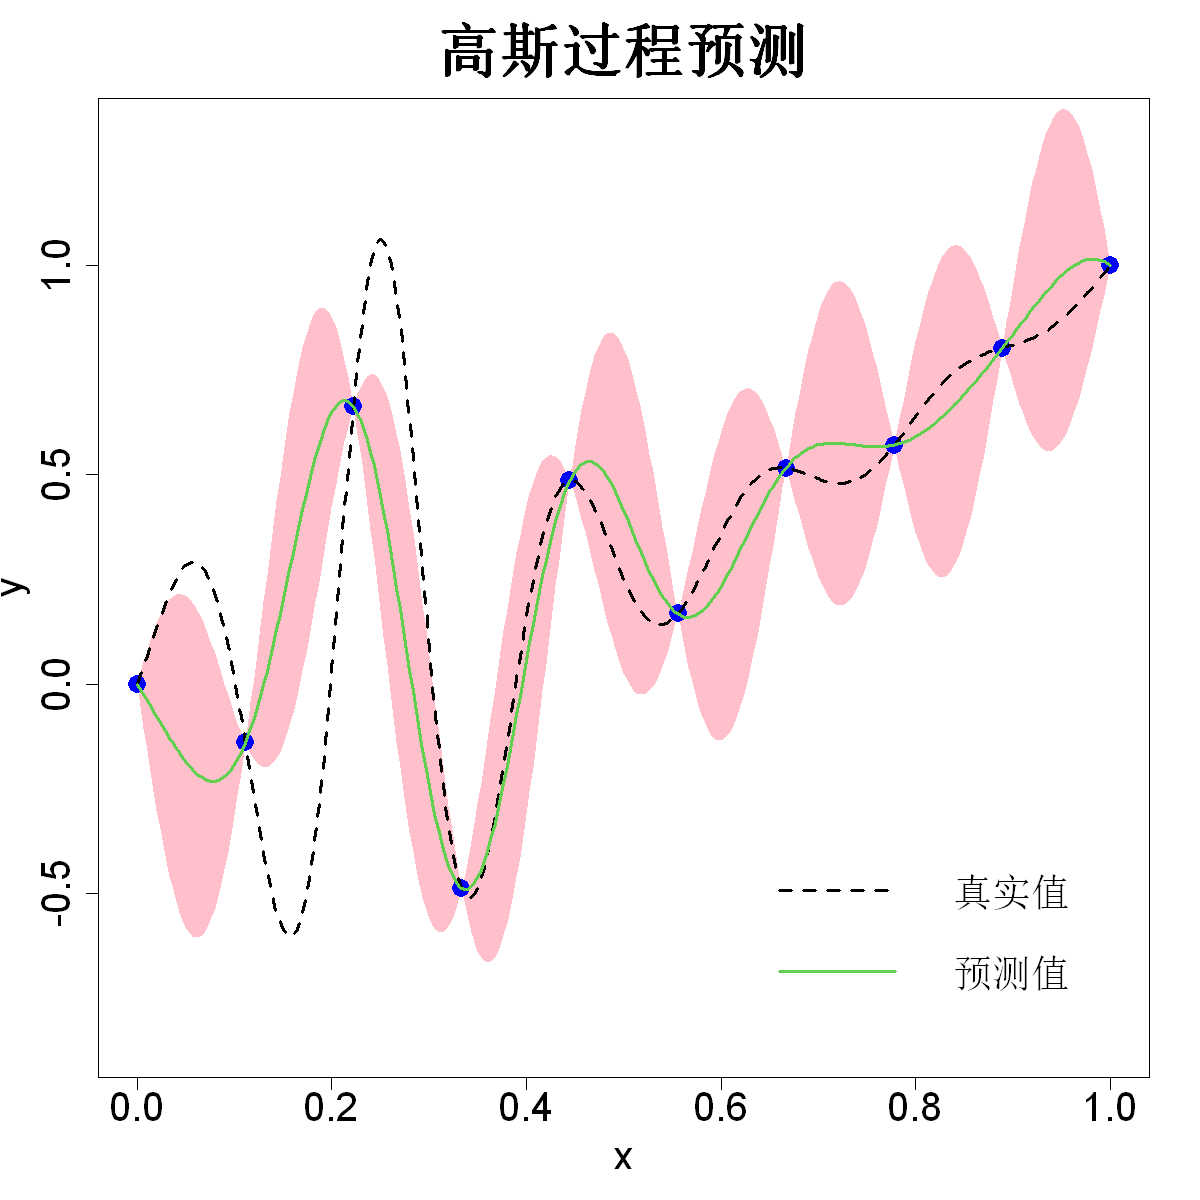

In [8]:
options(repr.plot.width=10,repr.plot.height=10)
library(DiceKriging)
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
test=matrix(seq(0,1,length=301),ncol=1,dimnames=list(NULL,"x"))
true=f(test[,1])
n=10
D=matrix(((1:n)-1)/(n-1),ncol=1,dimnames=list(NULL,"x"))
y=f(D[,1])
km.model=km(~1,design=as.matrix(D),response=y,covtype="gauss",coef.cov=0.067,coef.var=0.215,penalty=FALSE,control=list(trace=FALSE))
pred.obj=predict(km.model,as.matrix(test),type="SK")
pred=pred.obj$mean
MSE=pred.obj$sd^2
low=as.numeric(pred-2*sqrt(pmax(MSE,0)))
up=as.numeric(pred+2*sqrt(pmax(MSE,0)))
plot(test,true,type="n",xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程预测",cex.main=3,cex.lab=2,cex.axis=2)
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border=NA)
points(cbind(D,y),pch=16,cex=2,col="blue")
lines(test,true,lty=2,lwd=3)
lines(test,pred,col=3,lwd=3)
legend(.6,-.3,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,3),bty="n",cex=2)